#### Libs and configs

In [1]:
import sys
from pathlib import Path

project_dir = Path.cwd().parent

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

In [2]:
import pandas as pd
import numpy as np

from src.preprocessing.match_samples import propensity_score_match

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency

In [3]:
custom_params = {'axes.spines.right': False, 'axes.spines.top': False}
sns.set_theme(style='ticks', rc=custom_params)

#### Data

In [4]:
info = pd.read_csv('../data/demographics/info.csv', sep=';')

In [5]:
info.shape

(2645, 8)

#### Matching with Propensity Score Matching (PSM)

In [6]:
matched_df = propensity_score_match(
    df=info,
    covariates=['dataset', 'age', 'sex', 'site', 'scanner', 'group'],
    target_col='label',
    positive_class='not-useful',
    ratio=2,
    caliper=0.05,
    random_state=42,
    verbose=True
)

[INFO] not-useful available: 201.
[INFO] useful available: 2444.
[INFO] Fitting logistic regression.
[INFO] Matching cases and controls.
[INFO] useful selected: 291.
[INFO] Total images: 492.


In [7]:
matched_df.shape

(492, 8)

##### Evaluation

Final composition

In [8]:
print('Total images:', len(matched_df))
print('Images per label:', matched_df.label.value_counts())

Total images: 492
Images per label: label
useful        291
not-useful    201
Name: count, dtype: int64


Age descriptive stats

In [9]:
(
    matched_df
    .groupby('label')
    .age
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75)
    )
    .round(2)
)

,n,mean,median,std,q1,q3
label,,,,,,
not-useful,201,56.27,61.0,19.79,45.0,70.0
useful,291,56.28,60.0,18.66,46.5,70.0


SMD and Mann-Whitney for age

In [10]:
useful_age = matched_df.query("label == 'useful'").age
not_useful_age = matched_df.query("label == 'not-useful'").age

pooled_std = np.sqrt((useful_age.var() + not_useful_age.var()) / 2)
age_smd = (useful_age.mean() - not_useful_age.mean()) / pooled_std

In [11]:
mannwhitney_result = mannwhitneyu(
    useful_age,
    not_useful_age,
    alternative='two-sided'
)

In [12]:
print('SMD:', age_smd)
print('Mann-Whitney p-value:', mannwhitney_result.pvalue)

# Simple interpretation:
if abs(age_smd) < 0.10:
    print('Age is well balanced.')
else:
    print('Age presents a possible imbalance.')

SMD: 0.00024536608385128454
Mann-Whitney p-value: 0.7304112906344907
Age is well balanced.


Age boxplot

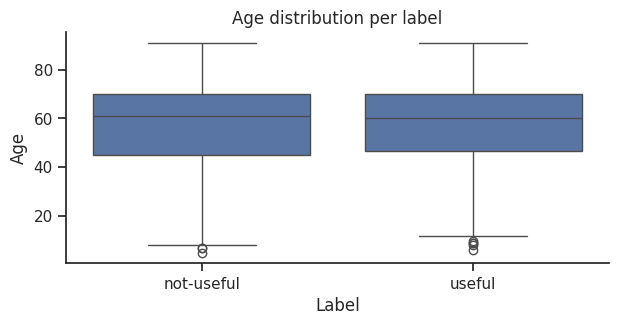

In [13]:
plt.figure(figsize=(7, 3))
sns.boxplot(
    data=matched_df,
    x='label',
    y='age'
)
plt.title('Age distribution per label')
plt.xlabel('Label')
plt.ylabel('Age')
plt.show()

Proportion for categoricals

In [14]:
categorical_columns = ['dataset', 'sex', 'site', 'scanner', 'group']

In [15]:
for column in categorical_columns:
    print('Distribution of', column)

    proportions = (
        pd.crosstab(
            matched_df[column],
            matched_df['label'],
            normalize='columns'
        )
        * 100
    )

    display(proportions.round(2))

Distribution of dataset


label,not-useful,useful
dataset,,
ADNI,8.96,10.65
IXI,20.90,25.09
PD-Campinas,6.97,7.22
PPMI,53.73,47.77
READISCA,1.49,1.03
TRACK-FA,7.96,8.25


Distribution of sex


label,not-useful,useful
sex,,
F,36.32,37.46
M,63.68,62.54


Distribution of site


label,not-useful,useful
site,,
116,0.50,1.03
126,0.50,1.03
127,0.50,0.69
13,0.50,1.37
131,1.00,0.34
133,2.49,2.75
14,2.49,2.06
16,0.50,1.03
19,5.47,6.87


Distribution of scanner


label,not-useful,useful
scanner,,
1.5T,41.29,32.99
3T,58.71,67.01


Distribution of group


label,not-useful,useful
group,,
healthy,35.82,34.71
unhealthy,64.18,65.29


Chi-squared test for categoricals

In [16]:
categorical_tests = []

for column in categorical_columns:
    contingency_table = pd.crosstab(
        matched_df[column], matched_df['label'])

    # No test if only one category.
    if contingency_table.shape[0] <= 1:
        categorical_tests.append({
            'variable': column,
            'test': 'no aplicable',
            'p_value': np.nan
        })

        continue

    chi_squared_result = chi2_contingency(contingency_table)

    categorical_tests.append({
        'variable': column,
        'test': 'chi-squared',
        'p_value': chi_squared_result.pvalue
    })

In [17]:
categorical_tests = pd.DataFrame(categorical_tests)
categorical_tests['p_value'] = categorical_tests['p_value'].round(4)

In [18]:
categorical_tests

,variable,test,p_value
0,dataset,chi-squared,0.8048
1,sex,chi-squared,0.8712
2,site,chi-squared,0.6990
3,scanner,chi-squared,0.0740
4,group,chi-squared,0.8744


Categorical plots

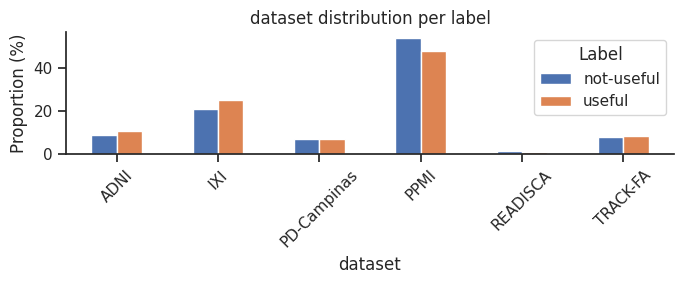

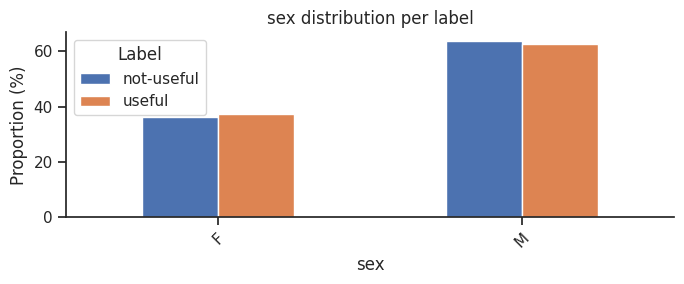

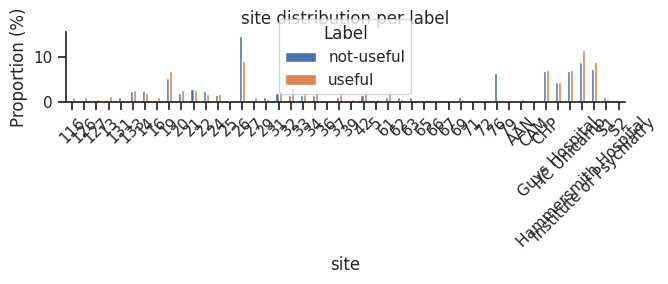

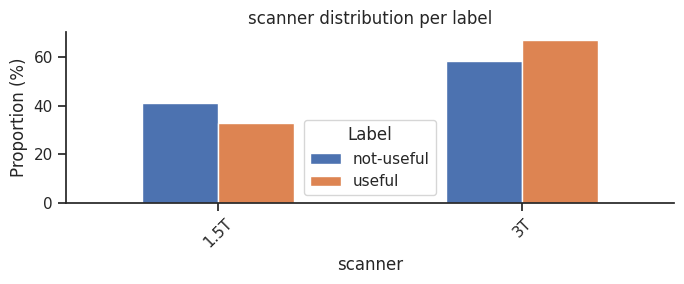

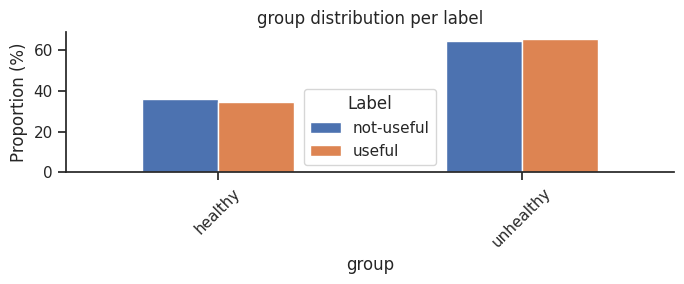

In [19]:
for column in categorical_columns:
    proportions = (
        pd.crosstab(
            matched_df[column],
            matched_df['label'],
            normalize='columns',
        )
        * 100
    )

    proportions.plot(
        kind="bar",
        figsize=(7, 3),
    )

    plt.title(f"{column} distribution per label")
    plt.xlabel(column)
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()

##### Saving PSM matched dataset

In [20]:
matched_df.to_csv('../data/demographics/matched_psm_info.csv', sep=';', index=False)

#### Matching with Coarsened Exact Matching (CEM)

##### Evaluation

##### Saving CEM matched dataset